# Notebook 2 — Data Check (Quality, Coverage, and Validation)

**Goal:** Validate the data before segmentation, basket creation, and rule mining.

This notebook:
- Checks all tables again with a validation focus (shape, duplicates, missing values)
- Checks explicit missing values and implicit missingness in `orders`
- Validates key consistency across tables (`order_id`, `product_id`, `aisle_id`, `department_id`)
- Validates value ranges and basic logic in `orders`
- Checks whether the orders we use cover departments and aisles (PRIOR and TRAIN)
- Prepares clean summary tables that will support the next notebooks

In [6]:
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
def load_instacart_tables():
    """
    Load Instacart tables from CSV files.

    Returns
    -------
    dict
        Main Instacart tables.
    """
    tables = {
        "orders": pd.read_csv("../data/orders.csv"),
        "order_products__prior": pd.read_csv("../data/order_products__prior.csv"),
        "order_products__train": pd.read_csv("../data/order_products__train.csv"),
        "products": pd.read_csv("../data/products.csv"),
        "aisles": pd.read_csv("../data/aisles.csv"),
        "departments": pd.read_csv("../data/departments.csv"),
    }
    return tables


def enrich_products(products, aisles, departments):
    """
    Merge products with aisles and departments.

    Returns
    -------
    DataFrame
        Enriched products table.
    """
    df = products.merge(aisles, on="aisle_id", how="left")
    df = df.merge(departments, on="department_id", how="left")
    return df


def overview_table(df, name):
    """
    Quick overview of a table.

    Returns
    -------
    DataFrame
        One row summary.
    """
    row = {
        "table": name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    }
    return pd.DataFrame([row])


def missing_report(df, name):
    """
    Count explicit missing values by column.

    Returns
    -------
    DataFrame
        Missing count and percentage per column.
    """
    miss = df.isna().sum().reset_index()
    miss.columns = ["column", "missing_count"]
    miss["missing_pct"] = miss["missing_count"] / len(df) if len(df) else 0.0
    miss["table"] = name
    miss = miss.sort_values("missing_count", ascending=False)
    return miss[["table", "column", "missing_count", "missing_pct"]]


def implicit_missing_orders(orders):
    """
    Check implicit missingness in orders.

    Here, missing `days_since_prior_order` is expected for first orders
    (order_number == 1). This function checks if that logic is respected.

    Returns
    -------
    DataFrame
        Summary of implicit missingness logic.
    """
    ds_missing = orders["days_since_prior_order"].isna()
    first_order = orders["order_number"] == 1

    return pd.DataFrame([{
        "days_since_prior_missing": int(ds_missing.sum()),
        "first_orders": int(first_order.sum()),
        "missing_and_first": int((ds_missing & first_order).sum()),
        "missing_but_not_first": int((ds_missing & ~first_order).sum()),
    }])


def duplicate_summary(tables_dict):
    """
    Count duplicate rows for all tables.

    Parameters
    ----------
    tables_dict : dict
        Dictionary of tables.

    Returns
    -------
    DataFrame
        Duplicate rows per table.
    """
    rows = []
    for name, df in tables_dict.items():
        rows.append({
            "table": name,
            "duplicate_rows": int(df.duplicated().sum())
        })
    return pd.DataFrame(rows)


def check_key_consistency(orders, op_prior, op_train, products, aisles, departments):
    """
    Check key consistency across tables.

    Checks:
    - order_id in order_products exists in orders
    - product_id in order_products exists in products
    - aisle_id in products exists in aisles
    - department_id in products exists in departments

    Returns
    -------
    DataFrame
        Missing key counts.
    """
    orders_set = set(orders["order_id"].unique())
    products_set = set(products["product_id"].unique())
    aisles_set = set(aisles["aisle_id"].unique())
    departments_set = set(departments["department_id"].unique())

    prior_missing_order = int((~op_prior["order_id"].isin(orders_set)).sum())
    prior_missing_product = int((~op_prior["product_id"].isin(products_set)).sum())

    train_missing_order = int((~op_train["order_id"].isin(orders_set)).sum())
    train_missing_product = int((~op_train["product_id"].isin(products_set)).sum())

    products_missing_aisle = int((~products["aisle_id"].isin(aisles_set)).sum())
    products_missing_department = int((~products["department_id"].isin(departments_set)).sum())

    return pd.DataFrame([
        {
            "check": "order_products__prior -> orders/products",
            "missing_order_id": prior_missing_order,
            "missing_product_id": prior_missing_product
        },
        {
            "check": "order_products__train -> orders/products",
            "missing_order_id": train_missing_order,
            "missing_product_id": train_missing_product
        },
        {
            "check": "products -> aisles/departments",
            "missing_order_id": np.nan,
            "missing_product_id": np.nan,
            "missing_aisle_id": products_missing_aisle,
            "missing_department_id": products_missing_department
        }
    ])


def check_orders_ranges(orders):
    """
    Validate basic ranges and simple logic in orders.

    Checks:
    - order_dow in [0, 6]
    - order_hour_of_day in [0, 23]
    - days_since_prior_order in [0, 30] when not missing
    - order_number >= 1

    Returns
    -------
    DataFrame
        Invalid counts.
    """
    bad_dow = int((~orders["order_dow"].between(0, 6)).sum())
    bad_hour = int((~orders["order_hour_of_day"].between(0, 23)).sum())
    bad_days = int((~orders["days_since_prior_order"].dropna().between(0, 30)).sum())
    bad_order_number = int((orders["order_number"] < 1).sum())

    return pd.DataFrame([{
        "bad_order_dow": bad_dow,
        "bad_order_hour_of_day": bad_hour,
        "bad_days_since_prior_order": bad_days,
        "bad_order_number": bad_order_number
    }])


def check_orders_evalset_values(orders):
    """
    Check values in the eval_set column of orders.

    Returns
    -------
    DataFrame
        Counts by eval_set and unknown values count.
    """
    counts = orders["eval_set"].value_counts(dropna=False).reset_index()
    counts.columns = ["eval_set", "n_orders"]

    valid_values = {"prior", "train", "test"}
    unknown_count = int((~orders["eval_set"].isin(valid_values)).sum())

    counts["unknown_values_count"] = 0
    if len(counts) > 0:
        counts.loc[counts.index[0], "unknown_values_count"] = unknown_count

    return counts


def check_unique_constraints(orders, products, aisles, departments):
    """
    Check if ID columns are unique in dimension tables.

    Returns
    -------
    DataFrame
        Duplicate ID counts for key columns.
    """
    rows = [
        {"table": "orders", "id_column": "order_id", "duplicate_ids": int(orders["order_id"].duplicated().sum())},
        {"table": "products", "id_column": "product_id", "duplicate_ids": int(products["product_id"].duplicated().sum())},
        {"table": "aisles", "id_column": "aisle_id", "duplicate_ids": int(aisles["aisle_id"].duplicated().sum())},
        {"table": "departments", "id_column": "department_id", "duplicate_ids": int(departments["department_id"].duplicated().sum())},
    ]
    return pd.DataFrame(rows)


def department_coverage(order_products, products_enriched, label):
    """
    Compute department coverage for a selected order_products table.

    Returns
    -------
    DataFrame
        Department counts and share for the given scope.
    """
    tmp = order_products.merge(products_enriched[["product_id", "department"]], on="product_id", how="left")
    dep = tmp.groupby("department").size().reset_index(name="n_lines")
    dep["share"] = dep["n_lines"] / dep["n_lines"].sum()
    dep["scope"] = label
    dep = dep.sort_values("n_lines", ascending=False)
    return dep[["scope", "department", "n_lines", "share"]]


def aisle_coverage(order_products, products_enriched, label, top_n=20):
    """
    Compute aisle coverage for a selected order_products table.

    Returns
    -------
    DataFrame
        Aisle counts and share (top aisles).
    """
    tmp = order_products.merge(products_enriched[["product_id", "aisle"]], on="product_id", how="left")
    ais = tmp.groupby("aisle").size().reset_index(name="n_lines")
    ais["share"] = ais["n_lines"] / ais["n_lines"].sum()
    ais["scope"] = label
    ais = ais.sort_values("n_lines", ascending=False).head(top_n)
    return ais[["scope", "aisle", "n_lines", "share"]]


def compare_department_coverage_plot(dep_prior, dep_train, top_n=15):
    """
    Plot department share comparison for PRIOR and TRAIN.

    Parameters
    ----------
    dep_prior : DataFrame
        Department coverage for PRIOR.
    dep_train : DataFrame
        Department coverage for TRAIN.
    top_n : int
        Number of top departments to display.
    """
    # Keep top departments from PRIOR to make comparison readable
    top_deps = dep_prior.head(top_n)["department"].tolist()

    p = dep_prior[dep_prior["department"].isin(top_deps)].copy()
    t = dep_train[dep_train["department"].isin(top_deps)].copy()

    plot_df = pd.concat([p, t], ignore_index=True)

    plt.figure(figsize=(11, 5))
    sns.barplot(data=plot_df, x="department", y="share", hue="scope")
    plt.title("Department share comparison (PRIOR vs TRAIN)")
    plt.xlabel("department")
    plt.ylabel("share")
    plt.xticks(rotation=45, ha="right")
    plt.show()


def compare_aisle_coverage_plot(ais_prior, ais_train):
    """
    Plot aisle share comparison for top aisles.

    Parameters
    ----------
    ais_prior : DataFrame
        Aisle coverage for PRIOR.
    ais_train : DataFrame
        Aisle coverage for TRAIN.
    """
    top_aisles = ais_prior["aisle"].tolist()

    p = ais_prior.copy()
    t = ais_train[ais_train["aisle"].isin(top_aisles)].copy()

    plot_df = pd.concat([p, t], ignore_index=True)

    plt.figure(figsize=(11, 6))
    sns.barplot(data=plot_df, y="aisle", x="share", hue="scope")
    plt.title("Aisle share comparison (PRIOR vs TRAIN)")
    plt.xlabel("share")
    plt.ylabel("aisle")
    plt.show()


def check_order_products_duplicates_by_pair(op_df, label):
    """
    Check duplicate (order_id, product_id) pairs in order_products.

    Returns
    -------
    DataFrame
        Count of duplicated pairs.
    """
    dup_pairs = int(op_df.duplicated(subset=["order_id", "product_id"]).sum())
    return pd.DataFrame([{
        "table": label,
        "duplicate_order_product_pairs": dup_pairs
    }])


def compare_product_coverage(op_prior, op_train):
    """
    Compare product coverage between PRIOR and TRAIN.

    Returns
    -------
    DataFrame
        Number of unique products in each split and overlap.
    """
    prior_products = set(op_prior["product_id"].unique())
    train_products = set(op_train["product_id"].unique())

    overlap = len(prior_products.intersection(train_products))
    only_prior = len(prior_products - train_products)
    only_train = len(train_products - prior_products)

    return pd.DataFrame([{
        "unique_products_prior": len(prior_products),
        "unique_products_train": len(train_products),
        "overlap_products": overlap,
        "only_prior_products": only_prior,
        "only_train_products": only_train
    }])

In [8]:
tables = load_instacart_tables()

orders = tables["orders"]
op_prior = tables["order_products__prior"]
op_train = tables["order_products__train"]
products = tables["products"]
aisles = tables["aisles"]
departments = tables["departments"]

products_enriched = enrich_products(products, aisles, departments)

In [9]:
# 1) Quick overview of all tables
overview = pd.concat([
    overview_table(orders, "orders"),
    overview_table(op_prior, "order_products__prior"),
    overview_table(op_train, "order_products__train"),
    overview_table(products, "products"),
    overview_table(aisles, "aisles"),
    overview_table(departments, "departments"),
], ignore_index=True)

display(overview)

,table,rows,cols,missing_cells,duplicate_rows
0,orders,3421083,7,206209,0
1,order_products__prior,32434489,4,0,0
2,order_products__train,1384617,4,0,0
3,products,49688,4,0,0
4,aisles,134,2,0,0
5,departments,21,2,0,0


In [10]:
# 2) Explicit missing values (all tables)
display(missing_report(orders, "orders"))
display(missing_report(op_prior, "order_products__prior"))
display(missing_report(op_train, "order_products__train"))
display(missing_report(products, "products"))
display(missing_report(aisles, "aisles"))
display(missing_report(departments, "departments"))

,table,column,missing_count,missing_pct
6,orders,days_since_prior_order,206209,0.060276
1,orders,user_id,0,0.000000
0,orders,order_id,0,0.000000
2,orders,eval_set,0,0.000000
3,orders,order_number,0,0.000000
4,orders,order_dow,0,0.000000
5,orders,order_hour_of_day,0,0.000000


,table,column,missing_count,missing_pct
0,order_products__prior,order_id,0,0.0
1,order_products__prior,product_id,0,0.0
2,order_products__prior,add_to_cart_order,0,0.0
3,order_products__prior,reordered,0,0.0


,table,column,missing_count,missing_pct
0,order_products__train,order_id,0,0.0
1,order_products__train,product_id,0,0.0
2,order_products__train,add_to_cart_order,0,0.0
3,order_products__train,reordered,0,0.0


,table,column,missing_count,missing_pct
0,products,product_id,0,0.0
1,products,product_name,0,0.0
2,products,aisle_id,0,0.0
3,products,department_id,0,0.0


,table,column,missing_count,missing_pct
0,aisles,aisle_id,0,0.0
1,aisles,aisle,0,0.0


,table,column,missing_count,missing_pct
0,departments,department_id,0,0.0
1,departments,department,0,0.0


In [11]:
# 3) Implicit missingness (orders logic)
display(implicit_missing_orders(orders))

,days_since_prior_missing,first_orders,missing_and_first,missing_but_not_first
0,206209,206209,206209,0


In [12]:
# 4) Duplicate rows and duplicate key IDs
display(duplicate_summary({
    "orders": orders,
    "order_products__prior": op_prior,
    "order_products__train": op_train,
    "products": products,
    "aisles": aisles,
    "departments": departments
}))

display(check_unique_constraints(orders, products, aisles, departments))

,table,duplicate_rows
0,orders,0
1,order_products__prior,0
2,order_products__train,0
3,products,0
4,aisles,0
5,departments,0


,table,id_column,duplicate_ids
0,orders,order_id,0
1,products,product_id,0
2,aisles,aisle_id,0
3,departments,department_id,0


In [13]:
# 5) Duplicate (order_id, product_id) pairs in order_products
display(check_order_products_duplicates_by_pair(op_prior, "order_products__prior"))
display(check_order_products_duplicates_by_pair(op_train, "order_products__train"))

,table,duplicate_order_product_pairs
0,order_products__prior,0


,table,duplicate_order_product_pairs
0,order_products__train,0


In [14]:
# 6) Key consistency checks across tables
display(check_key_consistency(orders, op_prior, op_train, products, aisles, departments))

,check,missing_order_id,missing_product_id,missing_aisle_id,missing_department_id
0,order_products__prior -> orders/products,0.0,0.0,NaN,NaN
1,order_products__train -> orders/products,0.0,0.0,NaN,NaN
2,products -> aisles/departments,NaN,NaN,0.0,0.0


In [15]:
# 7) Value range checks and eval_set checks
display(check_orders_ranges(orders))
display(check_orders_evalset_values(orders))

,bad_order_dow,bad_order_hour_of_day,bad_days_since_prior_order,bad_order_number
0,0,0,0,0


,eval_set,n_orders,unknown_values_count
0,prior,3214874,0
1,train,131209,0
2,test,75000,0


In [16]:
# 8) Product coverage overlap between PRIOR and TRAIN
display(compare_product_coverage(op_prior, op_train))

,unique_products_prior,unique_products_train,overlap_products,only_prior_products,only_train_products
0,49677,39123,39115,10562,8


,scope,department,n_lines,share
19,PRIOR,produce,9479291,0.292260
7,PRIOR,dairy eggs,5414016,0.166922
20,PRIOR,snacks,2887550,0.089027
3,PRIOR,beverages,2690129,0.082940
10,PRIOR,frozen,2236432,0.068952
16,PRIOR,pantry,1875577,0.057827
2,PRIOR,bakery,1176787,0.036282
6,PRIOR,canned goods,1068058,0.032930
8,PRIOR,deli,1051249,0.032411
9,PRIOR,dry goods pasta,866627,0.026719


,scope,department,n_lines,share
19,TRAIN,produce,409087,0.295451
7,TRAIN,dairy eggs,217051,0.156759
20,TRAIN,snacks,118862,0.085845
3,TRAIN,beverages,114046,0.082366
10,TRAIN,frozen,100426,0.072530
16,TRAIN,pantry,81242,0.058675
2,TRAIN,bakery,48394,0.034951
6,TRAIN,canned goods,46799,0.033799
8,TRAIN,deli,44291,0.031988
9,TRAIN,dry goods pasta,38713,0.027959


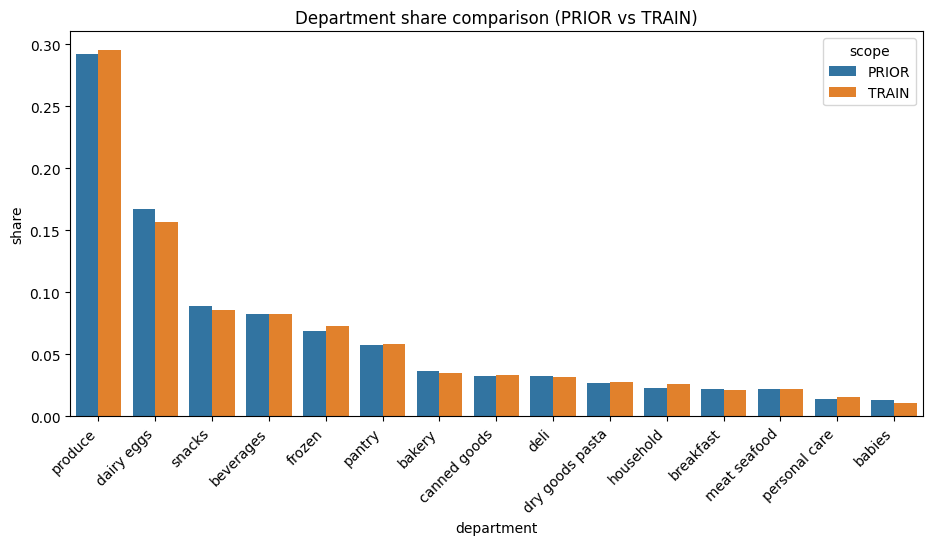

In [17]:
# 9) Department coverage check (important before mining)
dep_prior = department_coverage(op_prior, products_enriched, "PRIOR")
dep_train = department_coverage(op_train, products_enriched, "TRAIN")

display(dep_prior.head(20))
display(dep_train.head(20))

compare_department_coverage_plot(dep_prior, dep_train, top_n=15)

,scope,aisle,n_lines,share
50,PRIOR,fresh fruits,3642188,0.112294
53,PRIOR,fresh vegetables,3418021,0.105382
98,PRIOR,packaged vegetables fruits,1765313,0.054427
133,PRIOR,yogurt,1452343,0.044778
93,PRIOR,packaged cheese,979763,0.030207
83,PRIOR,milk,891015,0.027471
131,PRIOR,water seltzer sparkling water,841533,0.025946
25,PRIOR,chips pretzels,722470,0.022275
119,PRIOR,soy lactosefree,638253,0.019678
11,PRIOR,bread,584834,0.018031


,scope,aisle,n_lines,share
53,TRAIN,fresh vegetables,150609,0.108773
50,TRAIN,fresh fruits,150473,0.108675
98,TRAIN,packaged vegetables fruits,78493,0.056689
133,TRAIN,yogurt,55240,0.039896
93,TRAIN,packaged cheese,41699,0.030116
131,TRAIN,water seltzer sparkling water,36617,0.026446
83,TRAIN,milk,32644,0.023576
25,TRAIN,chips pretzels,31269,0.022583
119,TRAIN,soy lactosefree,26240,0.018951
11,TRAIN,bread,23635,0.017070


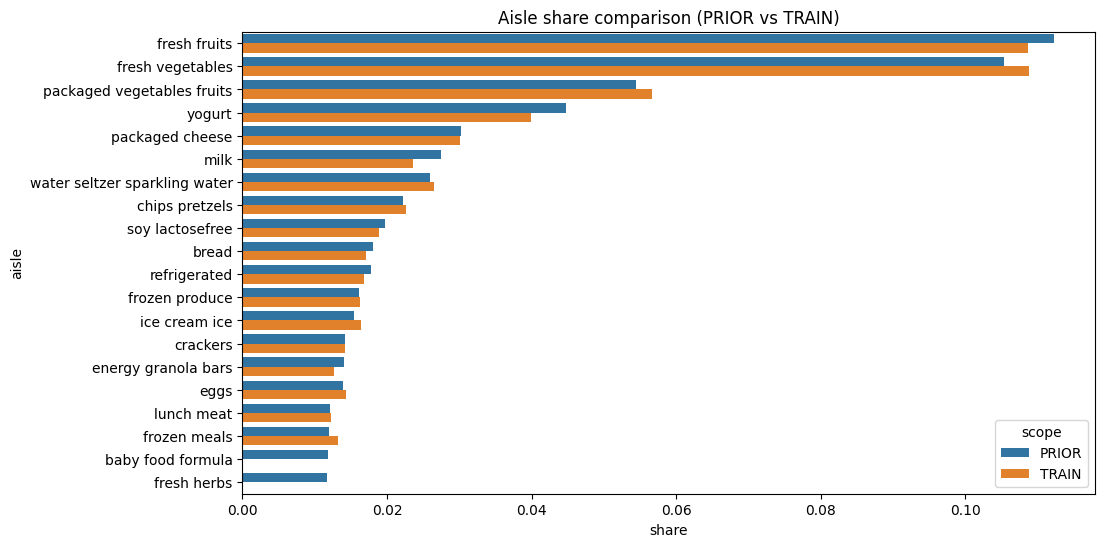

In [18]:
# 10) Aisle coverage check (important before mining)
ais_prior = aisle_coverage(op_prior, products_enriched, "PRIOR", top_n=20)
ais_train = aisle_coverage(op_train, products_enriched, "TRAIN", top_n=20)

display(ais_prior)
display(ais_train)

compare_aisle_coverage_plot(ais_prior, ais_train)